## Task 1: Problem Identification

✅ Image Classification

Explanation

The dataset contains images categorized into four classes:

- normal
- scratch
- dent
- stain

Each image belongs to only one category, and the model must predict a single label for every image.

This is the definition of an image classification problem.

It is not:

- Object Detection → no bounding boxes
- Semantic Segmentation → no pixel masks
- Instance Segmentation → no object-wise masks

## Task 2: Dataset Exploration

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# 1. Dataset Structure
df = pd.read_csv("labels.csv")

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  480 non-null    str  
 1   class     480 non-null    str  
dtypes: str(2)
memory usage: 7.6 KB
None
                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal


In [ ]:
# 2. Number of Classes
print(df['class'].unique())
print("Total Classes:", df['class'].nunique())

<StringArray>
['normal', 'scratch', 'dent', 'stain']
Length: 4, dtype: str
Total Classes: 4


In [ ]:
# 3. Number of Images Per Class
print(df['class'].value_counts())

class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


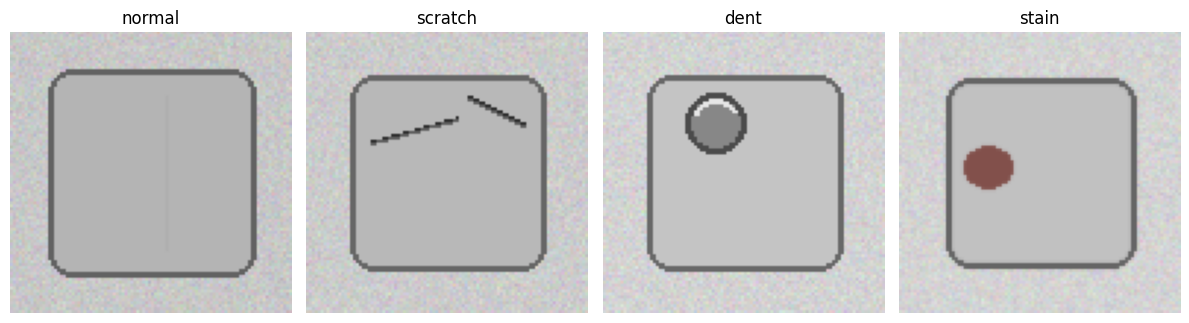

In [ ]:
# 4. Sample Images From Each Class


classes = df['class'].unique()

plt.figure(figsize=(12,4))

for i, cls in enumerate(classes):

    img_path = df[df['class']==cls]['filename'].iloc[0]

    img = Image.open(img_path)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 5. Image Dimensions
for path in df['filename'][:5]:
    img = Image.open(path)
    print(path, ":", img.size)

images/normal/normal_001.png : (96, 96)
images/normal/normal_002.png : (96, 96)
images/normal/normal_003.png : (96, 96)
images/normal/normal_004.png : (96, 96)
images/normal/normal_005.png : (96, 96)


<Axes: xlabel='class'>

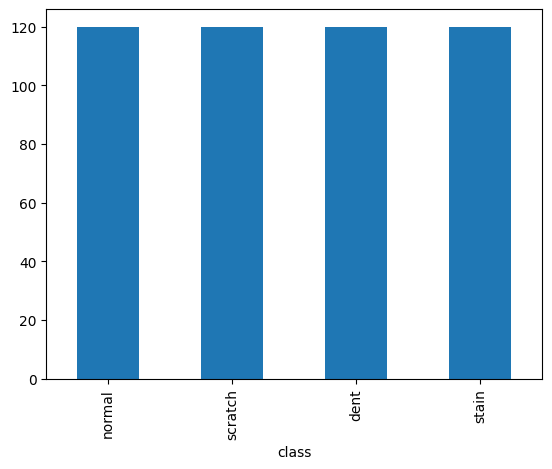

In [ ]:
# 6. Dataset Imbalance Check
df['class'].value_counts().plot(kind='bar')

## Task 3: Image Preprocessing

In [ ]:
# 1. Resize Images to Fixed Size
IMG_SIZE = 128

In [ ]:
img = Image.open(path)
img = img.resize((128,128))
img = np.array(img)
img = img / 255.0

In [ ]:
img = Image.open(df['filename'][0])
img_resized = img.resize((IMG_SIZE, IMG_SIZE))

In [ ]:
# 3. Convert Labels into Numerical Form
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(df['class'])
print(df.head())

                       filename   class  label_encoded
0  images/normal/normal_001.png  normal              1
1  images/normal/normal_002.png  normal              1
2  images/normal/normal_003.png  normal              1
3  images/normal/normal_004.png  normal              1
4  images/normal/normal_005.png  normal              1


In [ ]:
# 4. Load and Preprocess Images
import cv2
images = []
labels = []

for index, row in df.iterrows():
    img = cv2.imread(row['filename'])
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    images.append(img)
    labels.append(row['label_encoded'])

X = np.array(images)
y = np.array(labels)

In [ ]:
# 5. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 6. One-Hot Encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
# 7. Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

## Task 4: CNN Model Creation

In [ ]:
# CNN Model Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second CNN Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third CNN Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

e:\massai\codes\assignments\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Task 5: Model Training and Evaluation

In [ ]:
# 1. Train the CNN Model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 380ms/step - accuracy: 0.2135 - loss: 1.4827 - val_accuracy: 0.2500 - val_loss: 1.3870
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step - accuracy: 0.2578 - loss: 1.3877 - val_accuracy: 0.2500 - val_loss: 1.3745
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step - accuracy: 0.3516 - loss: 1.3422 - val_accuracy: 0.4375 - val_loss: 1.2519
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step - accuracy: 0.4583 - loss: 1.1773 - val_accuracy: 0.5625 - val_loss: 0.9804
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 345ms/step - accuracy: 0.5911 - loss: 0.9445 - val_accuracy: 0.8542 - val_loss: 0.7699
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - accuracy: 0.6823 - loss: 0.7366 - val_accuracy: 0.8542 - val_loss: 0.6930
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 421ms/step - accuracy: 0.7370 - loss: 0.6306 - val_accuracy: 0.8438 - val_loss: 0.4583
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step - accuracy: 0.7682 - loss: 0.6275 - val_accuracy: 0.

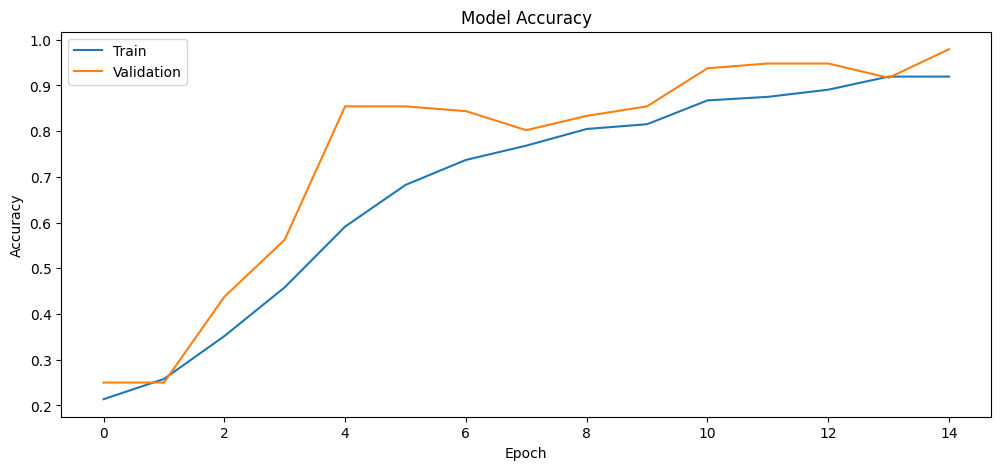

In [ ]:
# 2. Training Accuracy and Loss
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

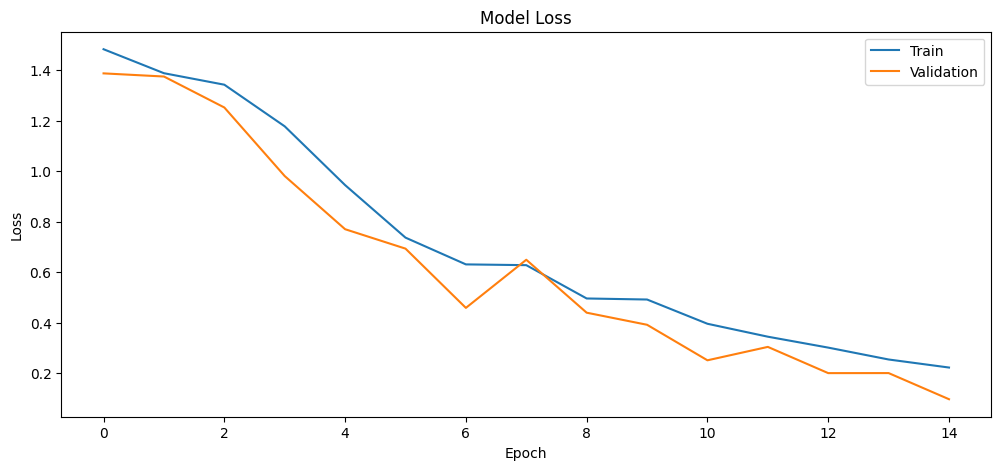

In [ ]:
# 3. Validation Accuracy and Loss
plt.figure(figsize=(12,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
# 4. Testing Performance    
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9792 - loss: 0.0966
Test Accuracy: 0.9791666865348816
Test Loss: 0.09663268178701401


In [ ]:
# 5. Confusion Matrix
from sklearn.metrics import confusion_matrix
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

print(cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
[[23  0  1  0]
 [ 0 24  0  0]
 [ 0  0 24  0]
 [ 1  0  0 23]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


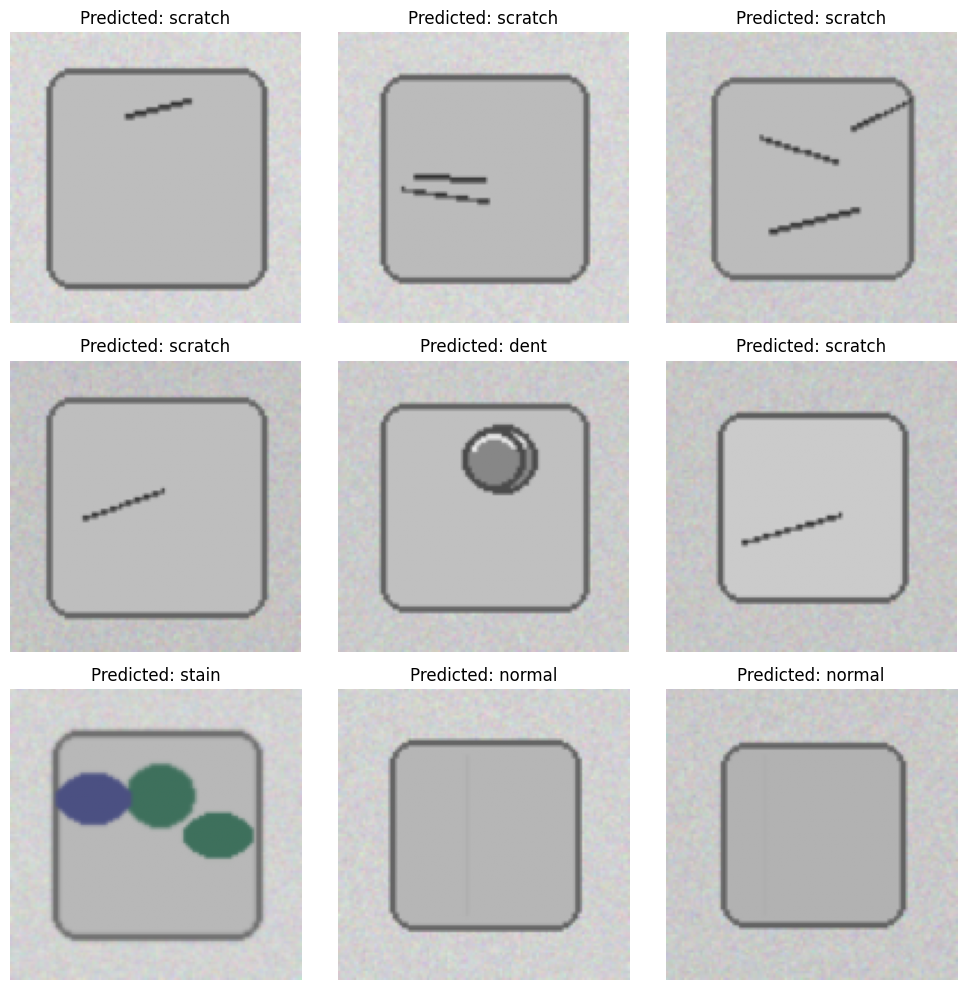

In [ ]:
# 6. Sample Predictions on Test Images
classes = encoder.classes_

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    pred = np.argmax(model.predict(
        np.expand_dims(X_test[i], axis=0)
    ))

    plt.title("Predicted: " + classes[pred])

    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 6: CNN Concept Explanation

1. What is Convolution?

Convolution is a mathematical operation where small filters scan across an image to detect features such as:

- edges
- textures
- patterns
- shapes

The CNN automatically learns these features during training.

2. Why is Pooling Used?

Pooling reduces the spatial size of feature maps.

Benefits:

- Reduces computation
- Reduces memory usage
- Helps prevent overfitting

Most common type : Max Pooling

3. Why is ReLU Commonly Used in CNNs?

ReLU stands for Rectified Linear Unit.

Formula:

f(x)=max(0,x)

Benefits:

- Faster training
- Handles non-linearity
- Reduces vanishing gradient problem
4. **Why are CNNs Better than Regular Feed-Forward Networks for Images?**

CNNs are designed specifically for image data because they:

- Preserve spatial information
- Automatically learn features
- Use fewer parameters
- Detect patterns effectively

Regular neural networks flatten images completely and lose spatial relationships.


## Task 7: Business Use Case Mapping
Manufacturing Quality Inspection

This computer vision system can be used in manufacturing industries for automated defect detection.

Workflow
1. Camera captures product images.
2. CNN analyzes surface quality.
3. Model classifies:
- normal
- scratch
- dent
- stain
4. Defective products are rejected automatically.